========== First 5 Rows ==========
  Payment_ID Student_ID Course  Amount Payment_Date Payment_Method  \
0    PAY0001    STU1002    MCA     999   2026-01-20    Net Banking   
1    PAY0002    STU1003  BTech     999   2026-04-15         Wallet   
2    PAY0003    STU1004    MBA    2999   2026-05-08           Card   
3    PAY0004    STU1005  BTech     499   2026-06-04         Wallet   
4    PAY0005    STU1006    MCA     499   2026-04-25           Card   

  Payment_Status   Gateway  Transaction_Fee  Net_Revenue     City      State  
0        Success  Razorpay            19.98       979.02  Lucknow         UP  
1         Failed      PayU            19.98         0.00   Ranchi  Jharkhand  
2        Success    Stripe            59.98      2939.02    Patna      Bihar  
3       Refunded      PayU             9.98         0.00  Lucknow         UP  
4         Failed      PayU             9.98         0.00   Ranchi  Jharkhand  

========== Dataset Shape ==========
(500, 12)

========== Dataset Inf

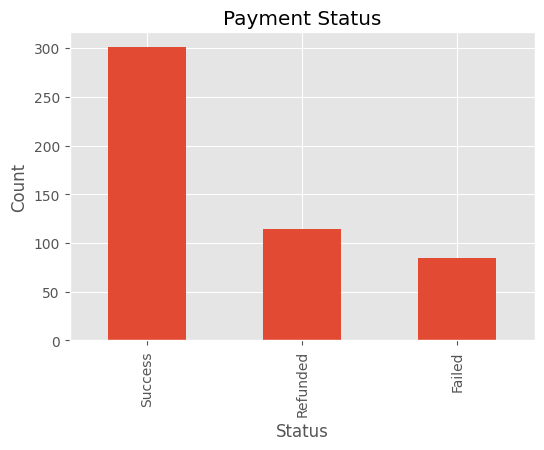

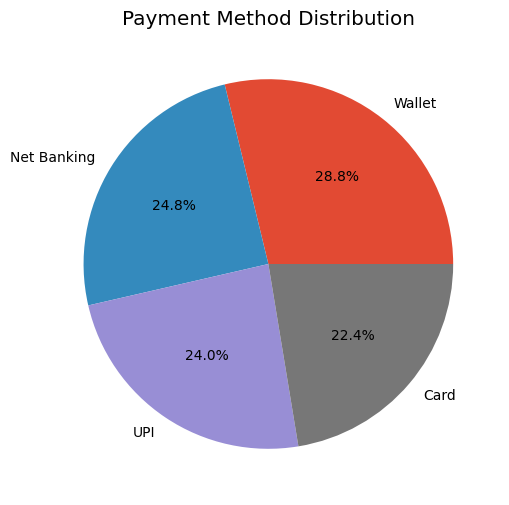

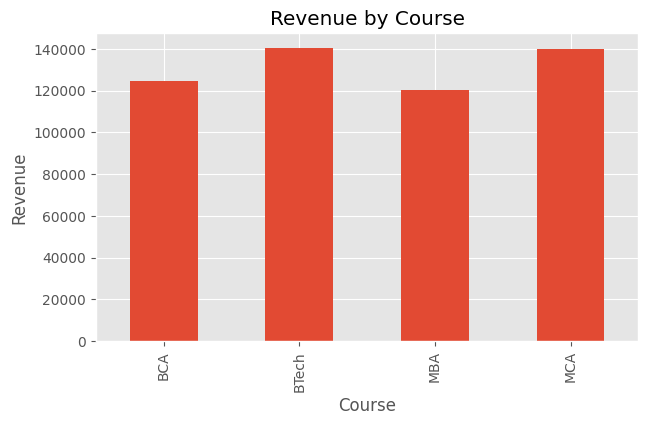

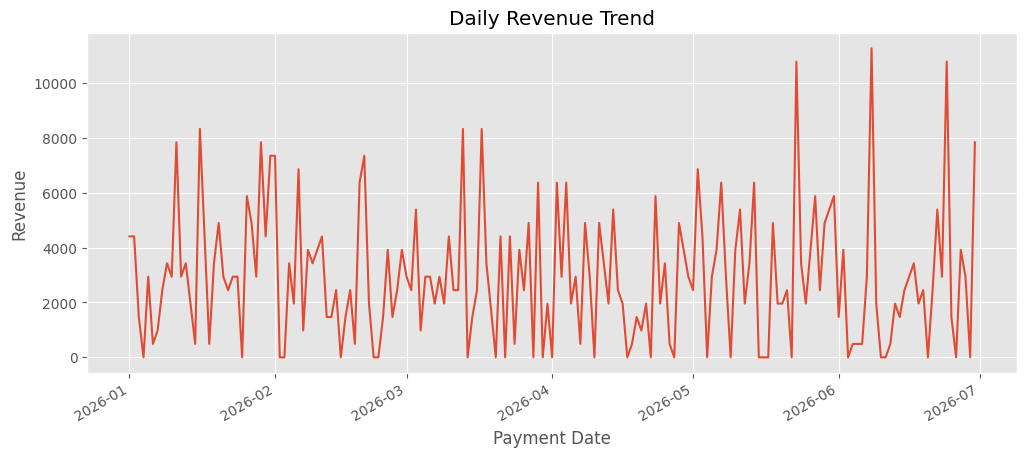

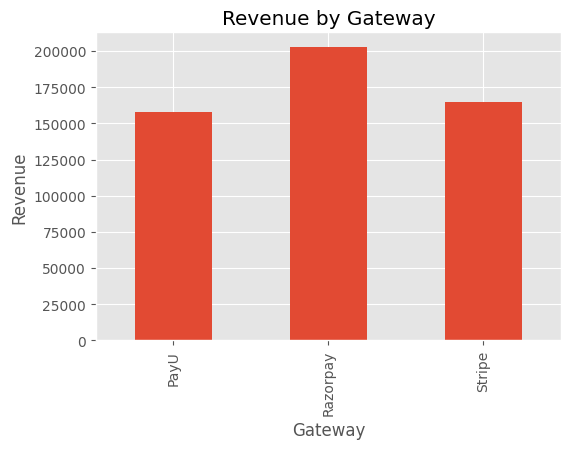

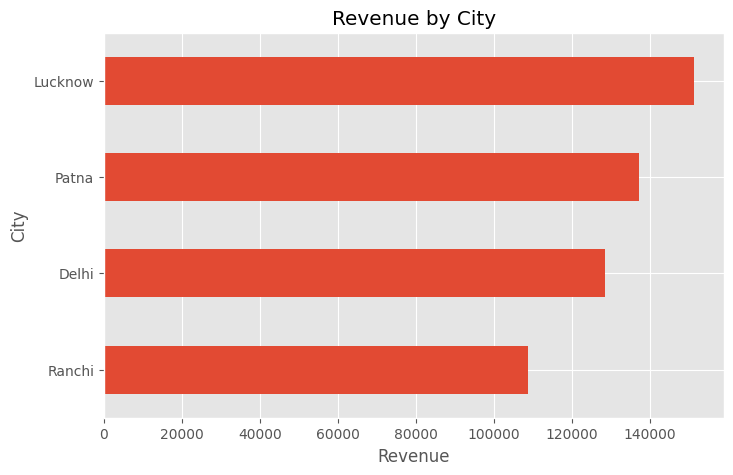


Cleaned Dataset Saved Successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Project Step 1 Completed Successfully!


In [1]:
# ============================
# TASK 06 - Revenue Analytics Project
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

# ----------------------------
# Read Excel Dataset
# ----------------------------

df = pd.read_excel("payments_dataset.xlsx")

print("========== First 5 Rows ==========")
print(df.head())

print("\n========== Dataset Shape ==========")
print(df.shape)

print("\n========== Dataset Info ==========")
print(df.info())

print("\n========== Statistical Summary ==========")
print(df.describe())

print("\n========== Missing Values ==========")
print(df.isnull().sum())

print("\n========== Duplicate Records ==========")
print(df.duplicated().sum())

# ----------------------------
# Remove Duplicates
# ----------------------------

df = df.drop_duplicates()

# ----------------------------
# Convert Date
# ----------------------------

df["Payment_Date"] = pd.to_datetime(df["Payment_Date"])

# ----------------------------
# KPI Metrics
# ----------------------------

total_revenue = df["Net_Revenue"].sum()
total_payments = len(df)
successful_payments = len(df[df["Payment_Status"]=="Success"])
failed_payments = len(df[df["Payment_Status"]=="Failed"])
refunded_payments = len(df[df["Payment_Status"]=="Refunded"])

print("\n==============================")
print("Revenue Dashboard Summary")
print("==============================")
print("Total Revenue :", total_revenue)
print("Total Payments :", total_payments)
print("Successful Payments :", successful_payments)
print("Failed Payments :", failed_payments)
print("Refunded Payments :", refunded_payments)

# ----------------------------
# Chart 1 : Payment Status
# ----------------------------

plt.figure(figsize=(6,4))
df["Payment_Status"].value_counts().plot(kind="bar")
plt.title("Payment Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

# ----------------------------
# Chart 2 : Payment Method
# ----------------------------

plt.figure(figsize=(6,6))
df["Payment_Method"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Payment Method Distribution")
plt.show()

# ----------------------------
# Chart 3 : Revenue by Course
# ----------------------------

plt.figure(figsize=(7,4))
df.groupby("Course")["Net_Revenue"].sum().plot(kind="bar")
plt.title("Revenue by Course")
plt.xlabel("Course")
plt.ylabel("Revenue")
plt.show()

# ----------------------------
# Chart 4 : Revenue Trend
# ----------------------------

plt.figure(figsize=(12,5))
daily = df.groupby("Payment_Date")["Net_Revenue"].sum()
daily.plot()
plt.title("Daily Revenue Trend")
plt.xlabel("Payment Date")
plt.ylabel("Revenue")
plt.show()

# ----------------------------
# Chart 5 : Gateway Revenue
# ----------------------------

plt.figure(figsize=(6,4))
df.groupby("Gateway")["Net_Revenue"].sum().plot(kind="bar")
plt.title("Revenue by Gateway")
plt.xlabel("Gateway")
plt.ylabel("Revenue")
plt.show()

# ----------------------------
# Chart 6 : Revenue by City
# ----------------------------

plt.figure(figsize=(8,5))
df.groupby("City")["Net_Revenue"].sum().sort_values().plot(kind="barh")
plt.title("Revenue by City")
plt.xlabel("Revenue")
plt.show()

# ----------------------------
# Save Clean Dataset
# ----------------------------

df.to_csv("cleaned_payments.csv", index=False)

print("\nCleaned Dataset Saved Successfully!")

# ----------------------------
# Download Clean Dataset
# ----------------------------

from google.colab import files
files.download("cleaned_payments.csv")

print("\nProject Step 1 Completed Successfully!")

In [2]:
# ==========================
# Advanced Revenue Metrics
# ==========================

success_df = df[df["Payment_Status"] == "Success"]

success_rate = (len(success_df) / len(df)) * 100

total_fees = df["Transaction_Fee"].sum()

average_revenue = success_df["Net_Revenue"].mean()

highest_course = df.groupby("Course")["Net_Revenue"].sum().idxmax()

highest_gateway = df.groupby("Gateway")["Net_Revenue"].sum().idxmax()

highest_city = df.groupby("City")["Net_Revenue"].sum().idxmax()

print("="*50)
print("ADVANCED REVENUE METRICS")
print("="*50)

print(f"Success Rate : {success_rate:.2f}%")
print(f"Total Transaction Fees : ₹{total_fees:.2f}")
print(f"Average Successful Revenue : ₹{average_revenue:.2f}")
print(f"Highest Revenue Course : {highest_course}")
print(f"Highest Revenue Gateway : {highest_gateway}")
print(f"Highest Revenue City : {highest_city}")

print("\nBusiness Insights")
print("- Highest revenue comes from:", highest_course)
print("- Best performing payment gateway:", highest_gateway)
print("- Top revenue generating city:", highest_city)
print("- Payment success rate:", f"{success_rate:.2f}%")

ADVANCED REVENUE METRICS
Success Rate : 60.20%
Total Transaction Fees : ₹18190.00
Average Successful Revenue : ₹1745.76
Highest Revenue Course : BTech
Highest Revenue Gateway : Razorpay
Highest Revenue City : Lucknow

Business Insights
- Highest revenue comes from: BTech
- Best performing payment gateway: Razorpay
- Top revenue generating city: Lucknow
- Payment success rate: 60.20%


In [3]:
readme = """
# Revenue Analytics Dashboard

## Project Overview
This project analyzes payment transaction data using Python, Pandas and Matplotlib.

## Features
- Revenue Metrics
- Payment Analysis
- Dashboard
- Business Insights

## Tools Used
- Python
- Google Colab
- Pandas
- Matplotlib
- Excel

## Author
Rituraj Singh
"""

with open("README.md", "w") as f:
    f.write(readme)

from google.colab import files
files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
requirements = """
pandas
numpy
matplotlib
openpyxl
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import os
import zipfile
import matplotlib.pyplot as plt
from google.colab import files

# Create folder
folder = "dashboard_charts"
os.makedirs(folder, exist_ok=True)

# Chart 1 - Payment Status
plt.figure(figsize=(6,4))
df["Payment_Status"].value_counts().plot(kind="bar")
plt.title("Payment Status")
plt.tight_layout()
plt.savefig(f"{folder}/01_payment_status.png", dpi=300)
plt.close()

# Chart 2 - Payment Method
plt.figure(figsize=(6,6))
df["Payment_Method"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"{folder}/02_payment_method.png", dpi=300)
plt.close()

# Chart 3 - Revenue by Course
plt.figure(figsize=(7,4))
df.groupby("Course")["Net_Revenue"].sum().plot(kind="bar")
plt.title("Revenue by Course")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig(f"{folder}/03_revenue_by_course.png", dpi=300)
plt.close()

# Chart 4 - Revenue Trend
plt.figure(figsize=(12,5))
df.groupby("Payment_Date")["Net_Revenue"].sum().plot()
plt.title("Daily Revenue Trend")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig(f"{folder}/04_revenue_trend.png", dpi=300)
plt.close()

# Chart 5 - Revenue by Gateway
plt.figure(figsize=(6,4))
df.groupby("Gateway")["Net_Revenue"].sum().plot(kind="bar")
plt.title("Revenue by Gateway")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig(f"{folder}/05_gateway_revenue.png", dpi=300)
plt.close()

# Chart 6 - Revenue by City
plt.figure(figsize=(8,5))
df.groupby("City")["Net_Revenue"].sum().sort_values().plot(kind="barh")
plt.title("Revenue by City")
plt.xlabel("Revenue")
plt.tight_layout()
plt.savefig(f"{folder}/06_city_revenue.png", dpi=300)
plt.close()

# Create ZIP
zip_name = "dashboard_charts.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:
    for file in os.listdir(folder):
        zipf.write(os.path.join(folder, file),
                   arcname=file)

print("✅ All charts saved successfully.")
print("📦 ZIP file created:", zip_name)

# Download ZIP
files.download(zip_name)

✅ All charts saved successfully.
📦 ZIP file created: dashboard_charts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>